In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("employee_turnover.csv")
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [3]:
df.isnull()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1346,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1347,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1348,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
df.isnull().sum()

Job_Satisfaction                           0
Performance_Rating                         0
Years_At_Company                           0
Work_Life_Balance                          0
Distance_From_Home                         0
Monthly_Income                             0
Education_Level                            0
Age                                        0
Num_Companies_Worked                       0
Employee_Role                              0
Annual_Bonus                               0
Training_Hours                             0
Department                                 0
Annual_Bonus_Squared                       0
Annual_Bonus_Training_Hours_Interaction    0
Employee_Turnover                          0
dtype: int64

**NOTE:** No need of preprocessing as there is no missing value adn the features are also in scale and there is categorical feature

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X=df.drop(columns=["Employee_Turnover"])
y=df["Employee_Turnover"]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(penalty=None)
log_model.fit(X_train,y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred=log_model.predict(X_test)
print(y_pred[0],y_test.iloc[0])

0 0


In [10]:
acc=log_model.score(X_test,y_test)
print("Accuracy is: ",acc)

Accuracy is:  0.8592592592592593


Confusion matrix
[[128  17]
 [ 21 104]]


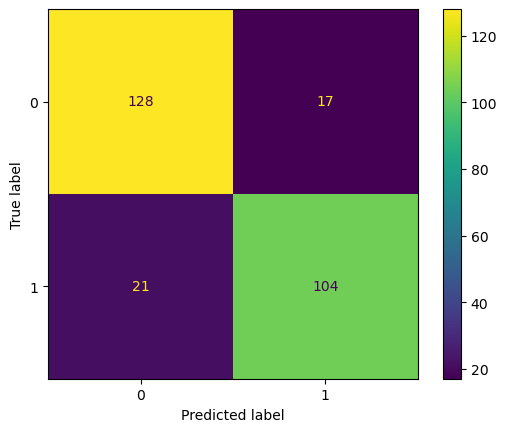

In [11]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
print("Confusion matrix")
print(cm)

disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=log_model.classes_)
disp.plot()

# REGULARISATION

In [13]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(penalty='l2',C=1)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc=model.score(X_test,y_test)
print("Accuracy is: ",acc)

Accuracy is:  0.8592592592592593


In [14]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(penalty='l1',C=1,solver='liblinear')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc=model.score(X_test,y_test)
print("Accuracy is: ",acc)

Accuracy is:  0.8666666666666667
